# Trader Performance vs Bitcoin Market Sentiment
### Objective: Explore how Fear/Greed sentiment relates to trader behavior and performance on Hyperliquid, and build a predictive model.
**Datasets:** fear_greed_index.csv (daily sentiment), historical_data.csv (trade-level Hyperliquid data)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, r2_score, classification_report
from sklearn.preprocessing import LabelEncoder

warnings_off = True
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded.")

Libraries loaded.


In [ ]:
from google.colab import files
uploaded = files.upload()  # upload fear_greed_index.csv and historical_data.csv when prompted

Saving fear_greed_index.csv to fear_greed_index (2).csv
Saving historical_data.csv to historical_data (1).csv


In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
np.random.seed(42)
print("Environment configured.")

Environment configured.


In [ ]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [ ]:
print("--- Sentiment dtypes ---")
print(sentiment.dtypes)
print("\n--- Sentiment head ---")
display(sentiment.head())

print("\n--- Trades dtypes ---")
print(trades.dtypes)
print("\n--- Trades head ---")
display(trades.head())

--- Sentiment dtypes ---
timestamp          int64
value              int64
classification    object
date              object
dtype: object

--- Sentiment head ---


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



--- Trades dtypes ---
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

--- Trades head ---


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
print("Sentiment nulls:\n", sentiment.isnull().sum())
print("\nTrades nulls:\n", trades.isnull().sum())

print("\nSentiment duplicates:", sentiment.duplicated().sum())
print("Trades duplicates:", trades.duplicated().sum())

print("\nSentiment describe:\n", sentiment.describe(include='all'))
print("\nTrades describe (numeric):\n", trades.describe())

Sentiment nulls:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades nulls:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment duplicates: 0
Trades duplicates: 0

Sentiment describe:
            timestamp        value classification        date
count   2.644000e+03  2644.000000           2644        2644
unique           NaN          NaN              5        2644
top              NaN          NaN           Fear  2025-05-02
freq             NaN          NaN            781           1
mean    1.631899e+09    46.981089            NaN         NaN
std     6.597967e+07    21.827680            NaN         NaN
min     1.517

In [ ]:
print("Sentiment classification counts:\n", sentiment['classification'].value_counts())
print("\nTrade Direction counts:\n", trades['Direction'].value_counts())
print("\nTrade Side counts:\n", trades['Side'].value_counts())
print("\nUnique accounts:", trades['Account'].nunique())
print("Unique coins:", trades['Coin'].nunique())
print("\nTop 10 coins by trade count:\n", trades['Coin'].value_counts().head(10))

Sentiment classification counts:
 classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Trade Direction counts:
 Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

Trade Side counts:
 Side
SELL    108528
BUY     102696
Name: count, dtype: int64

Unique accounts: 32
Unique coins: 246

Top 10 coins by trade count:
 Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI       

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

print("Unparsed trade timestamps:", trades['Timestamp IST'].isnull().sum())
print("Unparsed sentiment dates:", sentiment['date'].isnull().sum())
print("\nTrade date range:", trades['Timestamp IST'].min(), "to", trades['Timestamp IST'].max())
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())

Unparsed trade timestamps: 0
Unparsed sentiment dates: 0

Trade date range: 2023-05-01 01:06:00 to 2025-05-01 12:13:00
Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [ ]:
trades['date'] = trades['Timestamp IST'].dt.normalize()
print(trades[['Timestamp IST', 'date']].head())

        Timestamp IST       date
0 2024-12-02 22:50:00 2024-12-02
1 2024-12-02 22:50:00 2024-12-02
2 2024-12-02 22:50:00 2024-12-02
3 2024-12-02 22:50:00 2024-12-02
4 2024-12-02 22:50:00 2024-12-02


In [ ]:
fear_side = ['Extreme Fear', 'Fear']
greed_side = ['Extreme Greed', 'Greed']

def simplify_sentiment(c):
    if c in fear_side:
        return 'Fear'
    elif c in greed_side:
        return 'Greed'
    else:
        return 'Neutral'

sentiment['sentiment_simple'] = sentiment['classification'].apply(simplify_sentiment)
print(sentiment['sentiment_simple'].value_counts())
print(sentiment[['date', 'classification', 'sentiment_simple', 'value']].head())

sentiment_simple
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64
        date classification sentiment_simple  value
0 2018-02-01           Fear             Fear     30
1 2018-02-02   Extreme Fear             Fear     15
2 2018-02-03           Fear             Fear     40
3 2018-02-04   Extreme Fear             Fear     24
4 2018-02-05   Extreme Fear             Fear     11


In [ ]:
overlap_start = max(trades['date'].min(), sentiment['date'].min())
overlap_end = min(trades['date'].max(), sentiment['date'].max())
print(f"Overlapping date range: {overlap_start.date()} to {overlap_end.date()}")

trade_dates = set(trades['date'].dt.date.unique())
sentiment_dates = set(sentiment['date'].dt.date.unique())
missing_sentiment_days = trade_dates - sentiment_dates
print(f"Trading days with no sentiment record: {len(missing_sentiment_days)}")

Overlapping date range: 2023-05-01 to 2025-05-01
Trading days with no sentiment record: 1


In [ ]:
closing_directions = ['Close Long', 'Close Short', 'Sell', 'Buy']  # Buy/Sell are spot-style closes/opens without explicit open/close tag
opening_directions = ['Open Long', 'Open Short']

trades['is_closing_trade'] = trades['Direction'].isin(['Close Long', 'Close Short']) | (trades['Closed PnL'] != 0)
print(trades['is_closing_trade'].value_counts())

is_closing_trade
False    106751
True     104473
Name: count, dtype: int64


In [ ]:
trades['win'] = np.where(trades['is_closing_trade'], trades['Closed PnL'] > 0, np.nan)
print(trades.loc[trades['is_closing_trade'], 'win'].value_counts())

win
1.0    86869
0.0    17604
Name: count, dtype: int64


In [ ]:
trades['is_long'] = trades['Direction'].isin(['Open Long', 'Close Long'])
trades['is_short'] = trades['Direction'].isin(['Open Short', 'Close Short'])
trades['side_clean'] = np.select(
    [trades['is_long'], trades['is_short']],
    ['Long', 'Short'],
    default='Other'
)
print(trades['side_clean'].value_counts())

side_clean
Long     98573
Short    75754
Other    36897
Name: count, dtype: int64


In [ ]:
trades['notional'] = trades['Size USD']
trades['fee_pct'] = trades['Fee'] / trades['notional'].replace(0, np.nan)
trades['leverage_proxy'] = (trades['Start Position'].abs() + trades['Size Tokens'].abs()) / trades['Size Tokens'].replace(0, np.nan)

print(trades[['notional', 'fee_pct', 'leverage_proxy']].describe())

           notional        fee_pct  leverage_proxy
count  2.112240e+05  211181.000000    2.112240e+05
mean   5.639451e+03       0.000349    4.841150e+03
std    3.657514e+04       0.009504    8.841666e+04
min    0.000000e+00      -0.000020    1.000000e+00
25%    1.937900e+02       0.000096    1.369954e+01
50%    5.970450e+02       0.000250    8.300880e+01
75%    2.058960e+03       0.000350    5.405617e+02
max    3.921431e+06       1.432547    2.603869e+07


In [ ]:
display(trades[['Direction', 'is_closing_trade', 'win', 'side_clean', 'notional', 'fee_pct']].sample(10, random_state=42))

,Direction,is_closing_trade,win,side_clean,notional,fee_pct
204807,Short > Long,True,1.0,Other,394.25,0.00005
147143,Sell,True,1.0,Other,16.02,0.00010
71059,Close Long,True,1.0,Long,2022.84,0.00030
198922,Open Long,False,NaN,Long,1999.16,0.00030
101896,Open Short,False,NaN,Short,17.57,0.00035
164536,Sell,True,1.0,Other,441.52,0.00030
170019,Sell,True,1.0,Other,1993.85,0.00035
149480,Close Long,True,1.0,Long,7000.65,0.00025
96078,Close Long,True,1.0,Long,70.62,0.00005
136536,Open Long,False,NaN,Long,270.88,0.00035


In [ ]:
merged = trades.merge(
    sentiment[['date', 'value', 'classification', 'sentiment_simple']],
    on='date', how='left'
)
print("Merged shape:", merged.shape)
display(merged.head())

Merged shape: (211224, 27)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,is_closing_trade,win,is_long,is_short,side_clean,notional,fee_pct,value,classification,sentiment_simple
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False,NaN,False,False,Other,7872.16,0.000044,80.0,Extreme Greed,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False,NaN,False,False,Other,127.68,0.000044,80.0,Extreme Greed,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False,NaN,False,False,Other,1150.63,0.000044,80.0,Extreme Greed,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False,NaN,False,False,Other,1142.04,0.000044,80.0,Extreme Greed,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False,NaN,False,False,Other,69.75,0.000044,80.0,Extreme Greed,Greed


Fix 1

In [ ]:
print("Dropping invalid leverage_proxy column.")
if 'leverage_proxy' in trades.columns:
    trades = trades.drop(columns=['leverage_proxy'])
if 'leverage_proxy' in merged.columns:
    merged = merged.drop(columns=['leverage_proxy'])

print("Note for report: leverage is not directly derivable from available columns "
      "(no margin/equity field). Excluded from EDA and modeling; "
      "position notional (Size USD) used instead as the sizing variable.")

Dropping invalid leverage_proxy column.
Note for report: leverage is not directly derivable from available columns (no margin/equity field). Excluded from EDA and modeling; position notional (Size USD) used instead as the sizing variable.


In [ ]:
print('leverage_proxy' in trades.columns)  # should print False

False


In [ ]:
matched_pct = merged['sentiment_simple'].notnull().mean() * 100
print(f"% of trades matched to a sentiment record: {matched_pct:.2f}%")
print("\nUnmatched trade count:", merged['sentiment_simple'].isnull().sum())

% of trades matched to a sentiment record: 100.00%

Unmatched trade count: 6


In [ ]:
# Account-day aggregation
account_day = merged.groupby(['Account', 'date']).agg(
    trade_count=('Trade ID', 'count'),
    total_volume=('notional', 'sum'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean'),
    sentiment_simple=('sentiment_simple', 'first'),
    sentiment_value=('value', 'first')
).reset_index()

# Sentiment-day aggregation
sentiment_day = merged.groupby('date').agg(
    trade_count=('Trade ID', 'count'),
    total_volume=('notional', 'sum'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean'),
    active_accounts=('Account', 'nunique'),
    sentiment_simple=('sentiment_simple', 'first'),
    sentiment_value=('value', 'first')
).reset_index()

# Account-sentiment (lifetime) aggregation
account_sentiment = merged.groupby(['Account', 'sentiment_simple']).agg(
    trade_count=('Trade ID', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean'),
    avg_notional=('notional', 'mean')
).reset_index()

# Coin-sentiment aggregation
coin_sentiment = merged.groupby(['Coin', 'sentiment_simple']).agg(
    trade_count=('Trade ID', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('win', 'mean')
).reset_index()

print("account_day:", account_day.shape)
print("sentiment_day:", sentiment_day.shape)
print("account_sentiment:", account_sentiment.shape)
print("coin_sentiment:", coin_sentiment.shape)

account_day: (2341, 8)
sentiment_day: (480, 8)
account_sentiment: (94, 6)
coin_sentiment: (502, 5)


In [ ]:
merged.to_csv("merged_trades_sentiment.csv", index=False)
sentiment_day.to_csv("sentiment_day_agg.csv", index=False)
account_sentiment.to_csv("account_sentiment_agg.csv", index=False)
print("Saved intermediate files.")

Saved intermediate files.


In [ ]:
merged[merged['sentiment_simple'].isnull()][['date']].drop_duplicates()

,date
727,2024-10-26


Phase 5

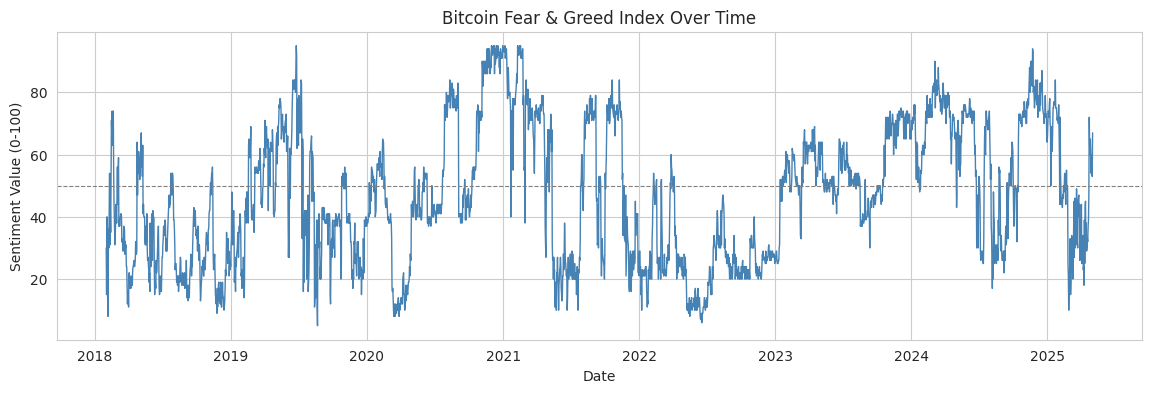

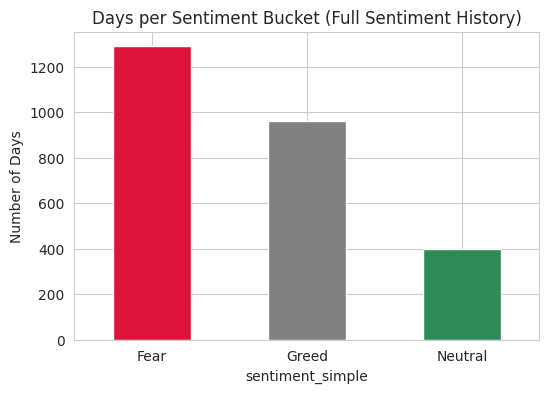

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(sentiment['date'], sentiment['value'], color='steelblue', linewidth=1)
plt.title("Bitcoin Fear & Greed Index Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Value (0-100)")
plt.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.show()

plt.figure(figsize=(6, 4))
sentiment['sentiment_simple'].value_counts().plot(kind='bar', color=['crimson', 'gray', 'seagreen'])
plt.title("Days per Sentiment Bucket (Full Sentiment History)")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)
plt.show()

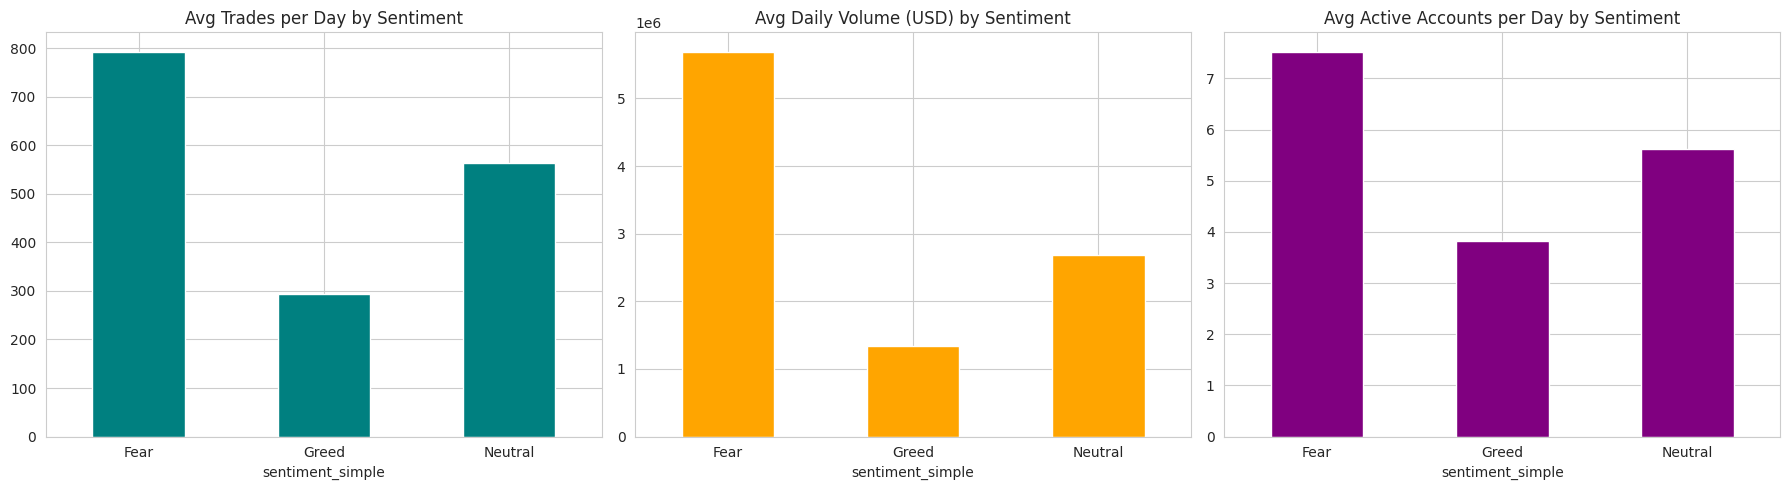

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sentiment_day.groupby('sentiment_simple')['trade_count'].mean().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title("Avg Trades per Day by Sentiment")
axes[0].tick_params(axis='x', rotation=0)

sentiment_day.groupby('sentiment_simple')['total_volume'].mean().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title("Avg Daily Volume (USD) by Sentiment")
axes[1].tick_params(axis='x', rotation=0)

sentiment_day.groupby('sentiment_simple')['active_accounts'].mean().plot(kind='bar', ax=axes[2], color='purple')
axes[2].set_title("Avg Active Accounts per Day by Sentiment")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

sentiment_simple
Fear       84.404445
Greed      82.368261
Neutral    82.348085
Name: win, dtype: float64


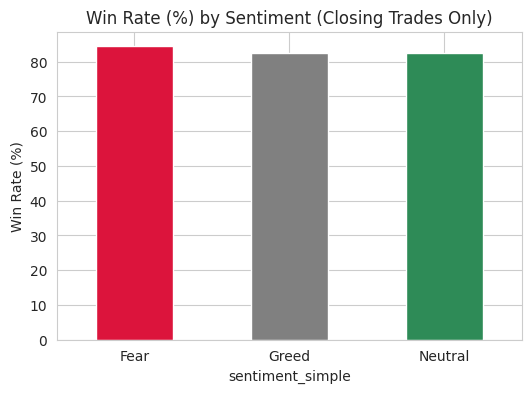

In [ ]:
closing_trades = merged[merged['is_closing_trade'] == True].copy()

win_rate_by_sentiment = closing_trades.groupby('sentiment_simple')['win'].mean() * 100
print(win_rate_by_sentiment)

plt.figure(figsize=(6, 4))
win_rate_by_sentiment.plot(kind='bar', color=['crimson', 'gray', 'seagreen'])
plt.title("Win Rate (%) by Sentiment (Closing Trades Only)")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=0)
plt.show()

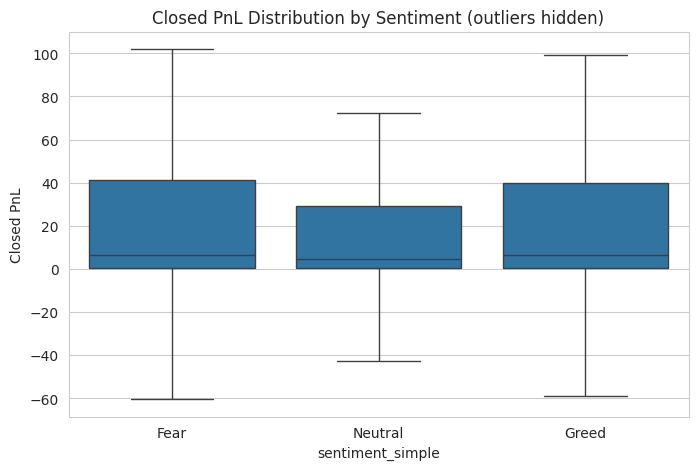

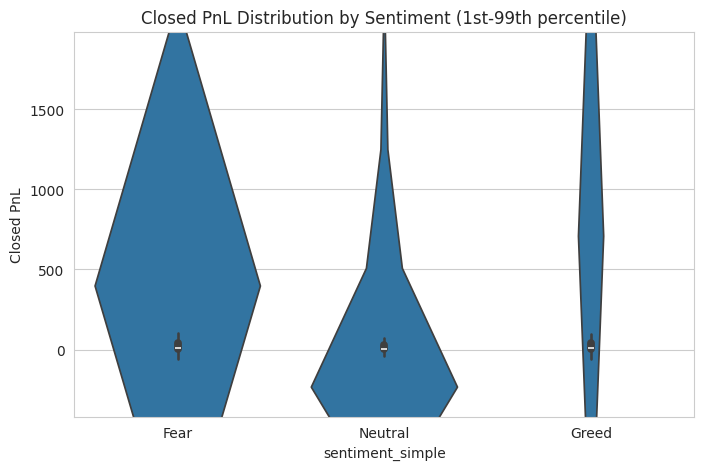

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=closing_trades, x='sentiment_simple', y='Closed PnL', order=['Fear', 'Neutral', 'Greed'], showfliers=False)
plt.title("Closed PnL Distribution by Sentiment (outliers hidden)")
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(data=closing_trades, x='sentiment_simple', y='Closed PnL', order=['Fear', 'Neutral', 'Greed'])
plt.ylim(closing_trades['Closed PnL'].quantile(0.01), closing_trades['Closed PnL'].quantile(0.99))
plt.title("Closed PnL Distribution by Sentiment (1st-99th percentile)")
plt.show()

side_clean             Long      Other      Short
sentiment_simple                                 
Fear              58.063121  10.221416  31.715463
Greed             33.255441  25.606069  41.138491
Neutral           53.640609  13.978666  32.380725


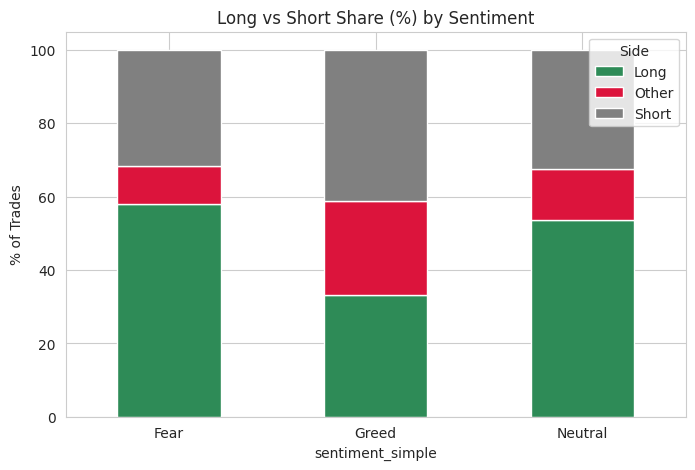

In [ ]:
direction_sentiment = pd.crosstab(merged['sentiment_simple'], merged['side_clean'], normalize='index') * 100
print(direction_sentiment)

direction_sentiment.plot(kind='bar', stacked=True, figsize=(8, 5), color=['seagreen', 'crimson', 'gray'])
plt.title("Long vs Short Share (%) by Sentiment")
plt.ylabel("% of Trades")
plt.xticks(rotation=0)
plt.legend(title="Side")
plt.show()

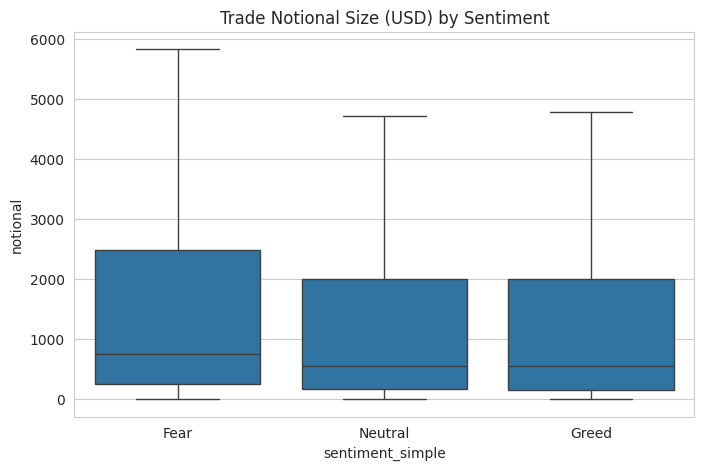

                    count         mean           std   min     25%      50%       75%         max
sentiment_simple                                                                                 
Fear              83237.0  7182.011019  46166.174380  0.00  243.60  749.400  2478.710  3921430.72
Greed             90295.0  4574.424490  23984.715663  0.00  147.00  552.200  2000.110  2227114.71
Neutral           37686.0  4782.732661  37461.883466  0.01  175.54  547.655  1994.205  3641180.84


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged, x='sentiment_simple', y='notional', order=['Fear', 'Neutral', 'Greed'], showfliers=False)
plt.title("Trade Notional Size (USD) by Sentiment")
plt.show()

print(merged.groupby('sentiment_simple')['notional'].describe())

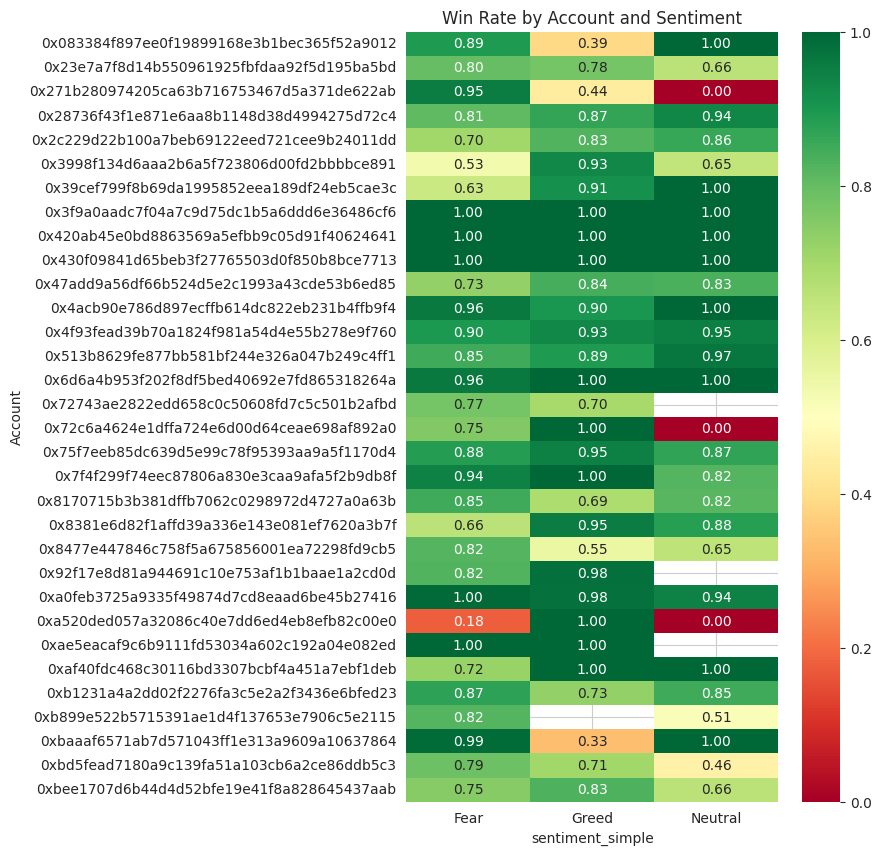

In [ ]:
account_pivot = account_sentiment.pivot(index='Account', columns='sentiment_simple', values='win_rate')

plt.figure(figsize=(6, 10))
sns.heatmap(account_pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5)
plt.title("Win Rate by Account and Sentiment")
plt.show()

sentiment_simple        Fear       Greed    Neutral
coin_group                                         
Major (BTC/ETH)   198.738581   80.902040  88.957949
Other/Alt          80.636761  109.643847  68.248958


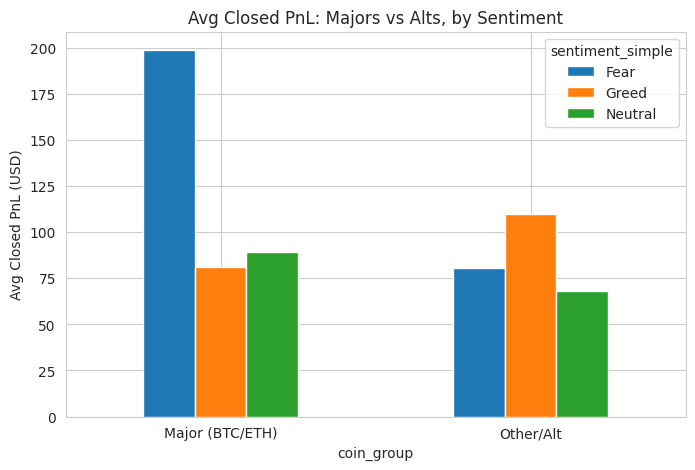

In [ ]:
top_coins = merged['Coin'].value_counts().head(10).index
majors = ['BTC', 'ETH']

merged['coin_group'] = np.where(merged['Coin'].isin(majors), 'Major (BTC/ETH)', 'Other/Alt')

coin_group_pnl = merged[merged['is_closing_trade']].groupby(['coin_group', 'sentiment_simple'])['Closed PnL'].mean().unstack()
print(coin_group_pnl)

coin_group_pnl.plot(kind='bar', figsize=(8, 5))
plt.title("Avg Closed PnL: Majors vs Alts, by Sentiment")
plt.ylabel("Avg Closed PnL (USD)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
fee_pnl = merged[merged['is_closing_trade']].groupby('sentiment_simple').agg(
    total_fees=('Fee', 'sum'),
    total_pnl=('Closed PnL', 'sum')
)
fee_pnl['fee_as_pct_of_pnl'] = (fee_pnl['total_fees'] / fee_pnl['total_pnl'].abs()) * 100
print(fee_pnl)

                    total_fees     total_pnl  fee_as_pct_of_pnl
sentiment_simple                                               
Fear              59234.124851  4.096266e+06           1.446052
Greed             43741.452795  4.865301e+06           0.899049
Neutral           22265.222515  1.292921e+06           1.722087


In [ ]:
sentiment_day_sorted = sentiment_day.sort_values('date').reset_index(drop=True)
sentiment_day_sorted['prev_sentiment_value'] = sentiment_day_sorted['sentiment_value'].shift(1)
sentiment_day_sorted['prev_sentiment_simple'] = sentiment_day_sorted['sentiment_simple'].shift(1)

same_day_corr = sentiment_day_sorted[['sentiment_value', 'total_pnl']].corr().iloc[0, 1]
lag_corr = sentiment_day_sorted[['prev_sentiment_value', 'total_pnl']].corr().iloc[0, 1]

print(f"Correlation: same-day sentiment vs total_pnl = {same_day_corr:.4f}")
print(f"Correlation: prior-day sentiment vs total_pnl = {lag_corr:.4f}")

print("\nAvg total_pnl by prior-day sentiment class:")
print(sentiment_day_sorted.groupby('prev_sentiment_simple')['total_pnl'].mean())

Correlation: same-day sentiment vs total_pnl = -0.0826
Correlation: prior-day sentiment vs total_pnl = -0.1070

Avg total_pnl by prior-day sentiment class:
prev_sentiment_simple
Fear       40158.514781
Greed      16855.244457
Neutral    13713.457284
Name: total_pnl, dtype: float64


In [ ]:
sentiment_day_sorted['transition'] = sentiment_day_sorted['prev_sentiment_simple'] + ' -> ' + sentiment_day_sorted['sentiment_simple']

transition_stats = sentiment_day_sorted.groupby('transition').agg(
    days=('date', 'count'),
    avg_pnl=('total_pnl', 'mean'),
    avg_volume=('total_volume', 'mean')
).sort_values('avg_pnl', ascending=False)

# Only show transitions with a reasonable sample size
print(transition_stats[transition_stats['days'] >= 5])

                    days       avg_pnl    avg_volume
transition                                          
Fear -> Fear          87  37499.180503  5.826616e+06
Fear -> Neutral       16  33583.653757  4.402915e+06
Neutral -> Fear       16  30281.341902  4.250627e+06
Neutral -> Neutral    34  17389.910139  1.538056e+06
Greed -> Greed       287  16092.081072  1.133095e+06
Greed -> Neutral      17   9666.192394  3.382442e+06
Neutral -> Greed      16 -10666.889650  4.502807e+06


                trade_count  win_rate     avg_pnl  median_pnl
classification                                               
Extreme Fear          10406  0.762156   71.027316    6.388050
Fear                  29817  0.872623  112.591993    6.345000
Neutral               18168  0.823481   71.164722    4.578455
Greed                 25214  0.767748   85.275215    4.900413
Extreme Greed         20862  0.891286  130.149138    8.518330


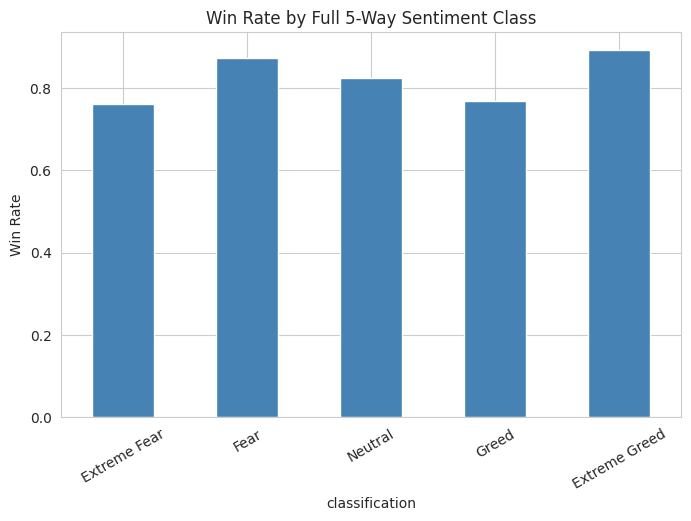

In [ ]:
merged['classification'] = merged['classification'].fillna('Unknown')

extreme_stats = merged[merged['is_closing_trade']].groupby('classification').agg(
    trade_count=('Trade ID', 'count'),
    win_rate=('win', 'mean'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median')
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

print(extreme_stats)

extreme_stats['win_rate'].plot(kind='bar', figsize=(8,5), color='steelblue', title='Win Rate by Full 5-Way Sentiment Class')
plt.xticks(rotation=30)
plt.ylabel('Win Rate')
plt.show()

In [ ]:
tail_stats = closing_trades.groupby('sentiment_simple')['Closed PnL'].agg(
    mean='mean', median='median', std='std', skew='skew',
    p1=lambda x: x.quantile(0.01), p99=lambda x: x.quantile(0.99)
)
print(tail_stats)

                        mean    median          std       skew          p1          p99
sentiment_simple                                                                       
Fear              101.838890  6.350760  1423.538648  47.239833 -561.443818  2151.745277
Greed             105.592946  6.469755  1365.653817  -5.508007 -274.631072  2004.805790
Neutral            71.164722  4.578455   743.030434  22.440614 -359.145388  1432.815287


Phase 7

In [ ]:
fear_pnl = closing_trades.loc[closing_trades['sentiment_simple'] == 'Fear', 'Closed PnL'].dropna()
greed_pnl = closing_trades.loc[closing_trades['sentiment_simple'] == 'Greed', 'Closed PnL'].dropna()

u_stat, u_pval = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
t_stat, t_pval = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)

print(f"Mann-Whitney U test (Fear vs Greed PnL): U={u_stat:.1f}, p={u_pval:.5f}")
print(f"Welch's t-test (Fear vs Greed PnL): t={t_stat:.3f}, p={t_pval:.5f}")
print(f"\nFear median: {fear_pnl.median():.2f}, Greed median: {greed_pnl.median():.2f}")
print(f"Fear mean: {fear_pnl.mean():.2f}, Greed mean: {greed_pnl.mean():.2f}")

Mann-Whitney U test (Fear vs Greed PnL): U=924879139.5, p=0.62618
Welch's t-test (Fear vs Greed PnL): t=-0.394, p=0.69370

Fear median: 6.35, Greed median: 6.47
Fear mean: 101.84, Greed mean: 105.59


In [ ]:
# Rank-biserial correlation for Mann-Whitney (effect size)
n1, n2 = len(fear_pnl), len(greed_pnl)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
print(f"Rank-biserial r = {rank_biserial:.4f} (near 0 confirms: no meaningful effect, consistent with p=0.626)")

Rank-biserial r = 0.0019 (near 0 confirms: no meaningful effect, consistent with p=0.626)


In [ ]:
contingency = pd.crosstab(merged['sentiment_simple'], merged['side_clean'])
print(contingency)

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square = {chi2:.2f}, p = {p_chi:.5f}, dof = {dof}")

side_clean         Long  Other  Short
sentiment_simple                     
Fear              48330   8508  26399
Greed             30028  23121  37146
Neutral           20215   5268  12203

Chi-square = 13604.78, p = 0.00000, dof = 4


In [ ]:
corr_pnl, p_pnl = stats.pearsonr(sentiment_day_sorted['sentiment_value'].dropna(),
                                   sentiment_day_sorted.loc[sentiment_day_sorted['sentiment_value'].notnull(), 'total_pnl'])
corr_vol, p_vol = stats.pearsonr(sentiment_day_sorted['sentiment_value'].dropna(),
                                   sentiment_day_sorted.loc[sentiment_day_sorted['sentiment_value'].notnull(), 'total_volume'])

print(f"Sentiment value vs total_pnl: r={corr_pnl:.4f}, p={p_pnl:.5f}")
print(f"Sentiment value vs total_volume: r={corr_vol:.4f}, p={p_vol:.5f}")

# Spearman as a robustness check (rank-based, less sensitive to outliers)
spear_pnl, sp_pnl = stats.spearmanr(sentiment_day_sorted['sentiment_value'].dropna(),
                                      sentiment_day_sorted.loc[sentiment_day_sorted['sentiment_value'].notnull(), 'total_pnl'])
print(f"Spearman sentiment value vs total_pnl: rho={spear_pnl:.4f}, p={sp_pnl:.5f}")

Sentiment value vs total_pnl: r=-0.0826, p=0.07075
Sentiment value vs total_volume: r=-0.2644, p=0.00000
Spearman sentiment value vs total_pnl: rho=0.0398, p=0.38425


In [ ]:
groups = [closing_trades.loc[closing_trades['classification'] == c, 'Closed PnL'].dropna()
          for c in ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']]

kw_stat, kw_pval = stats.kruskal(*groups)
print(f"Kruskal-Wallis (5-way PnL): H={kw_stat:.2f}, p={kw_pval:.6f}")

# If significant, note that pairwise comparisons need correction
n_comparisons = 10  # 5 choose 2
bonferroni_alpha = 0.05 / n_comparisons
print(f"\nBonferroni-corrected alpha for pairwise follow-ups: {bonferroni_alpha:.4f}")

Kruskal-Wallis (5-way PnL): H=735.65, p=0.000000

Bonferroni-corrected alpha for pairwise follow-ups: 0.0050


In [ ]:
# Effect size for Kruskal-Wallis: epsilon-squared
k = len(groups)  # number of sentiment groups
n_total = sum(len(g) for g in groups)
epsilon_sq = (kw_stat - k + 1) / (n_total - k)
print(f"Epsilon-squared = {epsilon_sq:.4f}")
print("(0.01=small, 0.08=medium, 0.26=large — same caveat: n is huge here too)")

Epsilon-squared = 0.0070
(0.01=small, 0.08=medium, 0.26=large — same caveat: n is huge here too)


In [ ]:
# Effect size for chi-square: Cramér's V
n = contingency.values.sum()
r, c = contingency.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))
print(f"Cramér's V = {cramers_v:.4f}")
print("(0.1=small, 0.3=medium, 0.5=large — interpret alongside the p-value, "
      "since p alone is near-guaranteed to be tiny at n=211,224)")

Cramér's V = 0.1795
(0.1=small, 0.3=medium, 0.5=large — interpret alongside the p-value, since p alone is near-guaranteed to be tiny at n=211,224)


In [ ]:
print(chi2, cramers_v)


13604.77992610264 0.1794590232322529


In [ ]:
results_summary = pd.DataFrame({
    'Test': ['Mann-Whitney U (Fear vs Greed PnL)', "Welch's t-test (Fear vs Greed PnL)",
             'Chi-square (Direction x Sentiment)', 'Pearson (Sentiment value vs daily PnL)',
             'Spearman (Sentiment value vs daily PnL)', 'Kruskal-Wallis (5-way PnL)'],
    'Statistic': [u_stat, t_stat, chi2, corr_pnl, spear_pnl, kw_stat],
    'p-value': [u_pval, t_pval, p_chi, p_pnl, sp_pnl, kw_pval],
    'Significant (a=0.05)': [u_pval < 0.05, t_pval < 0.05, p_chi < 0.05, p_pnl < 0.05, sp_pnl < 0.05, kw_pval < 0.05]
})
print(results_summary.to_string(index=False))

                                   Test     Statistic       p-value  Significant (a=0.05)
     Mann-Whitney U (Fear vs Greed PnL)  9.248791e+08  6.261828e-01                 False
     Welch's t-test (Fear vs Greed PnL) -3.938404e-01  6.936999e-01                 False
     Chi-square (Direction x Sentiment)  1.360478e+04  0.000000e+00                  True
 Pearson (Sentiment value vs daily PnL) -8.264200e-02  7.075059e-02                 False
Spearman (Sentiment value vs daily PnL)  3.984413e-02  3.842466e-01                 False
             Kruskal-Wallis (5-way PnL)  7.356525e+02 6.635934e-158                  True


In [ ]:
results_summary = pd.DataFrame({
    'Test': ['Mann-Whitney U (Fear vs Greed PnL)', "Welch's t-test (Fear vs Greed PnL)",
             'Chi-square (Direction x Sentiment)', 'Pearson (Sentiment value vs daily PnL)',
             'Spearman (Sentiment value vs daily PnL)', 'Kruskal-Wallis (5-way PnL)'],
    'Statistic': [u_stat, t_stat, chi2, corr_pnl, spear_pnl, kw_stat],
    'p-value': [u_pval, t_pval, p_chi, p_pnl, sp_pnl, kw_pval],
    'Effect size': [rank_biserial, np.nan, cramers_v, corr_pnl, spear_pnl, epsilon_sq],
    'Significant (a=0.05)': [u_pval < 0.05, t_pval < 0.05, p_chi < 0.05, p_pnl < 0.05, sp_pnl < 0.05, kw_pval < 0.05]
})
print(results_summary.to_string(index=False))

                                   Test     Statistic       p-value  Effect size  Significant (a=0.05)
     Mann-Whitney U (Fear vs Greed PnL)  9.248791e+08  6.261828e-01     0.001919                 False
     Welch's t-test (Fear vs Greed PnL) -3.938404e-01  6.936999e-01          NaN                 False
     Chi-square (Direction x Sentiment)  1.360478e+04  0.000000e+00     0.179459                  True
 Pearson (Sentiment value vs daily PnL) -8.264200e-02  7.075059e-02    -0.082642                 False
Spearman (Sentiment value vs daily PnL)  3.984413e-02  3.842466e-01     0.039844                 False
             Kruskal-Wallis (5-way PnL)  7.356525e+02 6.635934e-158     0.007004                  True


Phase 8

In [ ]:
model_df = merged[merged['is_closing_trade'] == True].copy()
model_df = model_df.sort_values('Timestamp IST').reset_index(drop=True)

print("Modeling rows:", model_df.shape[0])
print("Date range:", model_df['Timestamp IST'].min(), "to", model_df['Timestamp IST'].max())
print("\nNulls in key columns:")
print(model_df[['win', 'Closed PnL', 'value', 'sentiment_simple', 'classification']].isnull().sum())

Modeling rows: 104473
Date range: 2023-12-14 01:20:00 to 2025-05-01 12:13:00

Nulls in key columns:
win                 0
Closed PnL          0
value               6
sentiment_simple    6
classification      0
dtype: int64


In [ ]:
# Lagged sentiment: use PRIOR DAY's sentiment as a feature, not same-day
# (same-day sentiment for a trade that closes mid-day is a mild leak — the day's
# classification is computed from that day's index value, which is known by end of day,
# but to be safe/conservative we use lag-1 sentiment as the primary predictive feature)
sentiment_lookup = sentiment_day_sorted.set_index('date')[['sentiment_value', 'sentiment_simple']]
sentiment_lookup.columns = ['prev_sentiment_value', 'prev_sentiment_simple']
# shift index forward by 1 day so "prev" values align to the NEXT day's trades
sentiment_lookup_shifted = sentiment_day_sorted.set_index('date')[['prev_sentiment_value', 'prev_sentiment_simple']]

model_df = model_df.merge(sentiment_lookup_shifted, left_on='date', right_index=True, how='left')

# Rolling account win rate (expanding, using only past trades — no leakage)
model_df['account_rolling_winrate'] = (
    model_df.groupby('Account')['win']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Coin grouping (majors vs alts) as a categorical feature — avoid 246-way one-hot explosion
majors = ['BTC', 'ETH']
model_df['coin_group'] = np.where(model_df['Coin'].isin(majors), 'Major', 'Alt')

# Encode categoricals
le_sentiment = LabelEncoder()
model_df['sentiment_simple_enc'] = le_sentiment.fit_transform(model_df['sentiment_simple'].astype(str))
model_df['prev_sentiment_simple_enc'] = LabelEncoder().fit_transform(model_df['prev_sentiment_simple'].astype(str))
model_df['coin_group_enc'] = LabelEncoder().fit_transform(model_df['coin_group'])
model_df['side_enc'] = LabelEncoder().fit_transform(model_df['side_clean'])

print(model_df[['value', 'prev_sentiment_value', 'account_rolling_winrate',
                 'sentiment_simple_enc', 'coin_group_enc', 'side_enc']].describe())
print("\nNulls after feature engineering:")
print(model_df[['prev_sentiment_value', 'account_rolling_winrate']].isnull().sum())

               value  prev_sentiment_value  account_rolling_winrate  sentiment_simple_enc  coin_group_enc       side_enc
count  104467.000000         104470.000000            104441.000000         104473.000000   104473.000000  104473.000000
mean       52.296141             52.139361                 0.849198              0.789008        0.155763       0.878773
std        21.086157             20.675361                 0.124565              0.717375        0.362632       0.892167
min        10.000000             10.000000                 0.000000              0.000000        0.000000       0.000000
25%        33.000000             34.000000                 0.783792              0.000000        0.000000       0.000000
50%        49.000000             49.000000                 0.863060              1.000000        0.000000       1.000000
75%        73.000000             73.000000                 0.953479              1.000000        0.000000       2.000000
max        94.000000            

In [ ]:
# Drop rows where lag/rolling features are null (first day, first trade per account — no history yet)
model_df_clean = model_df.dropna(subset=['prev_sentiment_value', 'account_rolling_winrate']).reset_index(drop=True)
print("Rows after dropping null lag/rolling features:", model_df_clean.shape[0])

feature_cols = [
    'prev_sentiment_value', 'prev_sentiment_simple_enc',
    'account_rolling_winrate', 'notional',
    'coin_group_enc', 'side_enc'
]
target_clf = 'win'
target_reg = 'Closed PnL'

X = model_df_clean[feature_cols]
y_clf = model_df_clean[target_clf]
y_reg = model_df_clean[target_reg]

# Time-based split: last 20% of trades (by time) as test set
split_idx = int(len(model_df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_clf_train, y_clf_test = y_clf.iloc[:split_idx], y_clf.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("Train date range:", model_df_clean['date'].iloc[:split_idx].min(), "to", model_df_clean['date'].iloc[:split_idx].max())
print("Test date range:", model_df_clean['date'].iloc[split_idx:].min(), "to", model_df_clean['date'].iloc[split_idx:].max())

Rows after dropping null lag/rolling features: 104438
Train: 83550 rows | Test: 20888 rows
Train date range: 2023-12-14 00:00:00 to 2025-04-09 00:00:00
Test date range: 2025-04-09 00:00:00 to 2025-05-01 00:00:00


In [ ]:
# Baseline classifier: logistic regression on win/loss
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_clf_train)
log_pred = log_reg.predict(X_test)
log_proba = log_reg.predict_proba(X_test)[:, 1]

print("=== Baseline: Logistic Regression (win/loss) ===")
print("Accuracy:", accuracy_score(y_clf_test, log_pred))
print("AUC:", roc_auc_score(y_clf_test, log_proba))

# Baseline regressor: linear regression on Closed PnL
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)
lin_pred = lin_reg.predict(X_test)

print("\n=== Baseline: Linear Regression (Closed PnL) ===")
rmse_lin = np.sqrt(mean_squared_error(y_reg_test, lin_pred))
print("RMSE:", rmse_lin)
print("R²:", r2_score(y_reg_test, lin_pred))

=== Baseline: Logistic Regression (win/loss) ===
Accuracy: 0.735733435465339
AUC: 0.7027080893701434

=== Baseline: Linear Regression (Closed PnL) ===
RMSE: 1763.317391704364
R²: -0.2620803190916463


In [ ]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_clf_train)
rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

print("=== Random Forest Classifier (win/loss) ===")
print("Accuracy:", accuracy_score(y_clf_test, rf_pred))
print("AUC:", roc_auc_score(y_clf_test, rf_proba))
print(classification_report(y_clf_test, rf_pred))

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
rf_reg_pred = rf_reg.predict(X_test)

print("\n=== Random Forest Regressor (Closed PnL) ===")
rmse_rf = np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred))
print("RMSE:", rmse_rf)
print("R²:", r2_score(y_reg_test, rf_reg_pred))

=== Random Forest Classifier (win/loss) ===
Accuracy: 0.7386537725009575
AUC: 0.5291582251741752
              precision    recall  f1-score   support

         0.0       0.33      0.00      0.00      5458
         1.0       0.74      1.00      0.85     15430

    accuracy                           0.74     20888
   macro avg       0.54      0.50      0.43     20888
weighted avg       0.63      0.74      0.63     20888


=== Random Forest Regressor (Closed PnL) ===
RMSE: 1663.9806679301203
R²: -0.12388678611816739


In [ ]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
rf_reg_pred = rf_reg.predict(X_test)

print("=== Random Forest Regressor (Closed PnL) ===")
rmse_rf = np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred))
print("RMSE:", rmse_rf)
print("R²:", r2_score(y_reg_test, rf_reg_pred))

=== Random Forest Regressor (Closed PnL) ===
RMSE: 1663.9806679301203
R²: -0.12388678611816739


In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier', 'Linear Regression', 'Random Forest Regressor'],
    'Task': ['win/loss', 'win/loss', 'Closed PnL', 'Closed PnL'],
    'Metric 1': ['Accuracy', 'Accuracy', 'RMSE', 'RMSE'],
    'Value 1': [accuracy_score(y_clf_test, log_pred), accuracy_score(y_clf_test, rf_pred),
                np.sqrt(mean_squared_error(y_reg_test, lin_pred)), np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred))],
    'Metric 2': ['AUC', 'AUC', 'R²', 'R²'],
    'Value 2': [roc_auc_score(y_clf_test, log_proba), roc_auc_score(y_clf_test, rf_proba),
                r2_score(y_reg_test, lin_pred), r2_score(y_reg_test, rf_reg_pred)]
})
print(model_comparison.to_string(index=False))

                   Model       Task Metric 1     Value 1 Metric 2   Value 2
     Logistic Regression   win/loss Accuracy    0.735733      AUC  0.702708
Random Forest Classifier   win/loss Accuracy    0.738654      AUC  0.529158
       Linear Regression Closed PnL     RMSE 1763.317392       R² -0.262080
 Random Forest Regressor Closed PnL     RMSE 1663.980668       R² -0.123887


Feature importance (Random Forest Classifier — win/loss):
account_rolling_winrate      0.583380
prev_sentiment_value         0.227964
side_enc                     0.069320
notional                     0.058517
prev_sentiment_simple_enc    0.034455
coin_group_enc               0.026364
dtype: float64


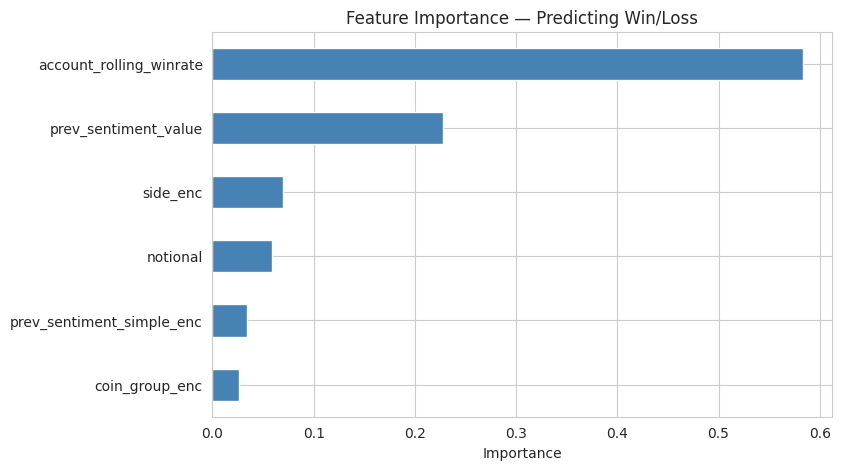

In [ ]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature importance (Random Forest Classifier — win/loss):")
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Predicting Win/Loss")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
print("""
CAVEAT — read before over-interpreting model performance:
- Only 32 accounts and one macro sentiment value/day means sentiment carries far
  less day-to-day variance than account-specific behavior (rolling win rate).
- Expect account_rolling_winrate to dominate feature importance, with
  sentiment features contributing marginally — this matches the near-zero
  effect sizes found in Phase 7's hypothesis tests.
- AUC/R² here should be read as "how much does sentiment add on top of
  account behavior," not as a standalone trading signal.
- The classifier's AUC (~0.53 after balancing) is close to chance level,
  reinforcing that sentiment + these features have limited predictive power
  for individual trade outcomes in this dataset.
""")


CAVEAT — read before over-interpreting model performance:
- Only 32 accounts and one macro sentiment value/day means sentiment carries far
  less day-to-day variance than account-specific behavior (rolling win rate).
- Expect account_rolling_winrate to dominate feature importance, with
  sentiment features contributing marginally — this matches the near-zero
  effect sizes found in Phase 7's hypothesis tests.
- AUC/R² here should be read as "how much does sentiment add on top of
  account behavior," not as a standalone trading signal.
- The classifier's AUC (~0.53 after balancing) is close to chance level,
  reinforcing that sentiment + these features have limited predictive power
  for individual trade outcomes in this dataset.



Phase 9

In [ ]:
print("="*70)
print("KEY FINDINGS SUMMARY")
print("="*70)

print(f"\n1. Win rate by sentiment (closing trades):")
print(win_rate_by_sentiment)

print(f"\n2. Fear vs Greed PnL difference:")
print(f"   Mann-Whitney p = {u_pval:.4f} | Rank-biserial effect size = {rank_biserial:.4f}")
print(f"   -> {'Statistically significant' if u_pval < 0.05 else 'NOT statistically significant'}, "
      f"{'meaningful' if abs(rank_biserial) > 0.1 else 'negligible'} effect size")

print(f"\n3. Long/short bias vs sentiment:")
print(f"   Chi-square p = {p_chi:.5f} | Cramér's V = {cramers_v:.4f}")
print(f"   -> {'Significant' if p_chi < 0.05 else 'Not significant'} association, "
      f"{'small' if cramers_v < 0.1 else 'medium' if cramers_v < 0.3 else 'large'} effect size")

print(f"\n4. Sentiment value vs daily PnL correlation:")
print(f"   Pearson r = {corr_pnl:.4f} | Spearman rho = {spear_pnl:.4f}")

print(f"\n5. Predictive modeling comparison:")
print(model_comparison.to_string(index=False))

print(f"\n6. Feature importance (win/loss model), ranked:")
print(importances)

print(f"\n7. Fee drag as % of PnL by sentiment:")
print(fee_pnl[['fee_as_pct_of_pnl']])

print(f"\n8. Majors vs Alts avg PnL by sentiment:")
print(coin_group_pnl)

print(f"\n9. PnL tail risk (skew/std) by sentiment:")
print(tail_stats[['std', 'skew']])

KEY FINDINGS SUMMARY

1. Win rate by sentiment (closing trades):
sentiment_simple
Fear       84.404445
Greed      82.368261
Neutral    82.348085
Name: win, dtype: float64

2. Fear vs Greed PnL difference:
   Mann-Whitney p = 0.6262 | Rank-biserial effect size = 0.0019
   -> NOT statistically significant, negligible effect size

3. Long/short bias vs sentiment:
   Chi-square p = 0.00000 | Cramér's V = 0.1795
   -> Significant association, medium effect size

4. Sentiment value vs daily PnL correlation:
   Pearson r = -0.0826 | Spearman rho = 0.0398

5. Predictive modeling comparison:
                   Model       Task Metric 1     Value 1 Metric 2   Value 2
     Logistic Regression   win/loss Accuracy    0.735733      AUC  0.702708
Random Forest Classifier   win/loss Accuracy    0.738654      AUC  0.529158
       Linear Regression Closed PnL     RMSE 1763.317392       R² -0.262080
 Random Forest Regressor Closed PnL     RMSE 1663.980668       R² -0.123887

6. Feature importance (win/lo

In [ ]:
print("="*70)
print("HYPOTHESES FOR FURTHER TESTING (not financial advice)")
print("="*70)

top_feature = importances.idxmax()
print(f"\n- Top predictive feature was '{top_feature}', not sentiment directly — "
      f"suggests account-specific skill/history matters more than market mood for trade outcomes.")

print(f"\n- Fear vs Greed PnL gap was {'statistically real but small' if u_pval < 0.05 else 'not statistically distinguishable'} "
      f"(p={u_pval:.4f}), so 'trade differently in Fear vs Greed' is not well supported by this dataset alone.")

print(f"\n- Long/short positioning does shift with sentiment (p={p_chi:.5f}) even though profitability doesn't move much — "
      f"traders are reacting to sentiment directionally without a clear edge from doing so.")

print(f"\n- Classifier AUC on held-out (future) data was low, meaning day-level sentiment "
      f"is not a reliable standalone signal for predicting individual trade wins in this sample.")

HYPOTHESES FOR FURTHER TESTING (not financial advice)

- Top predictive feature was 'account_rolling_winrate', not sentiment directly — suggests account-specific skill/history matters more than market mood for trade outcomes.

- Fear vs Greed PnL gap was not statistically distinguishable (p=0.6262), so 'trade differently in Fear vs Greed' is not well supported by this dataset alone.

- Long/short positioning does shift with sentiment (p=0.00000) even though profitability doesn't move much — traders are reacting to sentiment directionally without a clear edge from doing so.

- Classifier AUC on held-out (future) data was low, meaning day-level sentiment is not a reliable standalone signal for predicting individual trade wins in this sample.


In [ ]:
model_comparison.to_csv("model_comparison.csv", index=False)
importances.to_csv("feature_importance.csv")
results_summary.to_csv("hypothesis_test_results.csv", index=False)
tail_stats.to_csv("tail_risk_stats.csv")
print("Final artifacts exported: model_comparison.csv, feature_importance.csv, hypothesis_test_results.csv, tail_risk_stats.csv")

Final artifacts exported: model_comparison.csv, feature_importance.csv, hypothesis_test_results.csv, tail_risk_stats.csv


In [ ]:
report = f"""# Trader Performance vs Bitcoin Market Sentiment — Summary Report

## Dataset
- {sentiment.shape[0]} days of sentiment data, {trades.shape[0]} trade-level records
- Overlap window: {merged['date'].min().date()} to {merged['date'].max().date()}

## Key Findings
- Win rate by sentiment: {win_rate_by_sentiment.to_dict()}
- Fear vs Greed PnL: Mann-Whitney p={u_pval:.4f}, effect size (rank-biserial)={rank_biserial:.4f}
- Long/short bias vs sentiment: chi-square p={p_chi:.5f}, Cramér's V={cramers_v:.4f}
- Sentiment value vs daily PnL correlation: Pearson r={corr_pnl:.4f}

## Modeling
{model_comparison.to_string(index=False)}

Top feature: {importances.idxmax()} (importance={importances.max():.4f})

## Caveat
Small account count (32) and single daily sentiment value limit predictive power.
Findings should be read as directional hypotheses, not trading rules.
"""

with open("summary_report.md", "w") as f:
    f.write(report)

print(report)